## Deep FM model for Search Relevance Ranking

In [7]:
import pickle
import cloudpickle
from tqdm import tqdm
import random

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample

import torch
from torch.utils.data import Dataset, DataLoader

import json
from datetime import datetime

from deepctr_torch.models import DeepFM
from deepctr_torch.inputs import SparseFeat, DenseFeat, get_feature_names


In [8]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

## Data Loading & Preparation

In [9]:
df = pd.read_pickle('df_features_enriched.pkl')
print(df.shape)
print(df.dtypes)
print(df.memory_usage(deep=True).sum() / 1e6, "MB")

(54281, 31)
answers                   object
passages                  object
query                        str
query_id                   int32
query_type                   str
wellFormedAnswers         object
passage_text                 str
is_selected               object
label                      int64
query_length               int64
passage_length             int64
length_ratio             float64
exact_match                int64
query_term_coverage      float64
jaccard_similarity       float64
tfidf_cosine_sim         float64
bm25_score               float64
passage_position           int64
idf_weighted_coverage    float64
bigram_overlap           float64
trigram_overlap          float64
passage_has_number         int64
query_has_number           int64
both_have_number           int64
is_numeric                 int64
is_description             int64
is_entity                  int64
numeric_x_has_number       int64
description_x_length       int64
entity_x_exact_match       int6

### Features

In [10]:

df['query_type_encoded'] = LabelEncoder().fit_transform(df['query_type'].astype(str))

In [11]:
# Columns not to use as features: query, passage_text. passages, answers, wellFormedanswers, is_selected
# Columns to keep but not as features: query_id, label

# Dense Feat - continuous or numerical features
# Sparse Features - categorical features

dense_features = [
    'query_length', 'passage_length', 'length_ratio',
    'exact_match', 'query_term_coverage', 'jaccard_similarity',
    'tfidf_cosine_sim', 'bm25_score', 'passage_position',
    'idf_weighted_coverage', 'bigram_overlap', 'trigram_overlap',
    'passage_has_number', 'query_has_number', 'both_have_number',
    'is_numeric', 'is_description', 'is_entity',
    'numeric_x_has_number', 'description_x_length', 'entity_x_exact_match',
    'max_tfidf_term'
]

sparse_features = [
  'query_type_encoded'
]

In [12]:
scaler = StandardScaler()
df[dense_features] = scaler.fit_transform(df[dense_features])

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [13]:
fixlen_feature_columns = (
    [SparseFeat(feat, vocabulary_size=df[feat].nunique() + 1, embedding_dim=4) for feat in sparse_features] 
    +
    [DenseFeat(feat) for feat in dense_features]
)

feature_names = get_feature_names(fixlen_feature_columns)
print(f"Feature Names: {feature_names}")

Feature Names: ['query_type_encoded', 'query_length', 'passage_length', 'length_ratio', 'exact_match', 'query_term_coverage', 'jaccard_similarity', 'tfidf_cosine_sim', 'bm25_score', 'passage_position', 'idf_weighted_coverage', 'bigram_overlap', 'trigram_overlap', 'passage_has_number', 'query_has_number', 'both_have_number', 'is_numeric', 'is_description', 'is_entity', 'numeric_x_has_number', 'description_x_length', 'entity_x_exact_match', 'max_tfidf_term']


### Tran Test Split

In [14]:

# unique_queries = df['query_id'].unique()

# train_query_ids, test_query_ids = train_test_split(
#     unique_queries,
#     test_size=0.2,
#     random_state=42
# )


# train_df = df[df['query_id'].isin(train_query_ids)].reset_index(drop=True)
# test_df  = df[df['query_id'].isin(test_query_ids)].reset_index(drop=True)

# print(f"Train: {len(train_df):,} rows | {train_df['query_id'].nunique():,} queries")
# print(f"Test:  {len(test_df):,} rows  | {test_df['query_id'].nunique():,} queries")
# print(f"Avg passages per query — Train: {len(train_df)/train_df['query_id'].nunique():.1f}")
# print(f"Avg passages per query — Test:  {len(test_df)/test_df['query_id'].nunique():.1f}")


# print(f"\nPositive rate — Train: {train_df['label'].mean():.4f} | Test: {test_df['label'].mean():.4f}")

In [15]:
unique_qids = df['query_id'].unique()

train_qids, temp_qids = train_test_split(unique_qids, test_size=0.30, random_state=42)
val_qids, test_qids   = train_test_split(temp_qids,   test_size=0.50, random_state=42)

train_df = df[df['query_id'].isin(train_qids)].reset_index(drop=True)
val_df   = df[df['query_id'].isin(val_qids)].reset_index(drop=True)
test_df  = df[df['query_id'].isin(test_qids)].reset_index(drop=True)

### Preparing Input in Deepctr Torch Format


In [16]:
# def build_input(data, feature_names):
#     return {name: data[name].values for name in feature_names}

# train_input = build_input(train_df, feature_names)
# test_input  = build_input(test_df, feature_names)

# y_train = train_df['label'].values.astype(np.float32)
# y_test  = test_df['label'].values.astype(np.float32)

# neg = (df['label'] == 0).sum()
# pos = (df['label'] == 1).sum()
# pos_weight = neg / pos
# print(f"Positive weight: {pos_weight:.2f}")  # should be ~8.3

# sample_weights = np.where(y_train == 1, pos_weight, 1.0)

In [17]:
# Build inputs
def build_input(data, feature_names):
    return {name: data[name].values for name in feature_names}

train_input = build_input(train_df, feature_names)
val_input   = build_input(val_df,   feature_names)
test_input  = build_input(test_df,  feature_names)

y_train = train_df['label'].values.astype(np.float32)
y_val   = val_df['label'].values.astype(np.float32)
y_test  = test_df['label'].values.astype(np.float32)


In [18]:

# def build_input(data, feature_names):
#     return {name: data[name].values for name in feature_names}

# # Separate majority and minority classes
# train_majority = train_df[train_df['label'] == 0]
# train_minority = train_df[train_df['label'] == 1]

# print(f"Before — Majority: {len(train_majority):,} | Minority: {len(train_minority):,}")

# # Oversample minority to match majority
# train_minority_upsampled = resample(
#     train_minority,
#     replace=True,              # sample with replacement
#     n_samples=len(train_majority),
#     random_state=42
# )

# # Combine and shuffle
# train_balanced = pd.concat([train_majority, train_minority_upsampled])
# train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# print(f"After  — Majority: {(train_balanced['label']==0).sum():,} | Minority: {(train_balanced['label']==1).sum():,}")

# # Rebuild train input from balanced df
# train_input = build_input(train_balanced, feature_names)
# y_train = train_balanced['label'].values.astype(np.float32)

# test_input = build_input(test_df, feature_names)
# y_test = test_df['label'].values.astype(np.float32)

## DeepFM Model

In [19]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = DeepFM(
    linear_feature_columns=fixlen_feature_columns,
    dnn_feature_columns=fixlen_feature_columns,
    dnn_hidden_units=(128, 64, 32),
    # dnn_hidden_units =  (64, 32),
    dnn_dropout=0.3,
    task='binary',
    device=device
)

model.compile(
    optimizer='adam',
    # optimizer='adagrad', 
    loss='binary_crossentropy',
    metrics = ['binary_crossentropy', 'auc']
)

print(model)

Using device: cpu
DeepFM(
  (embedding_dict): ModuleDict(
    (query_type_encoded): Embedding(6, 4)
  )
  (linear_model): Linear(
    (embedding_dict): ModuleDict(
      (query_type_encoded): Embedding(6, 1)
    )
  )
  (out): PredictionLayer()
  (fm): FM()
  (dnn): DNN(
    (dropout): Dropout(p=0.3, inplace=False)
    (linears): ModuleList(
      (0): Linear(in_features=26, out_features=128, bias=True)
      (1): Linear(in_features=128, out_features=64, bias=True)
      (2): Linear(in_features=64, out_features=32, bias=True)
    )
    (activation_layers): ModuleList(
      (0-2): 3 x ReLU(inplace=True)
    )
  )
  (dnn_linear): Linear(in_features=32, out_features=1, bias=False)
)


### Model Training

In [20]:
history = model.fit(
    train_input, 
    y_train,
    batch_size=256,
    epochs = 20,
    # validation_split = 0.1,
    validation_data=(val_input, y_val),
    verbose = 1
)

torch.save(model.state_dict(), 'deepfm_best.pt')
print("Model saved to deepfm_best.pt")

cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch


149it [00:04, 32.90it/s]


Epoch 1/20
4s - loss:  0.4264 - binary_crossentropy:  0.4260 - auc:  0.6347 - val_binary_crossentropy:  0.3242 - val_auc:  0.6663


149it [00:03, 38.37it/s]


Epoch 2/20
4s - loss:  0.3208 - binary_crossentropy:  0.3209 - auc:  0.6788 - val_binary_crossentropy:  0.3234 - val_auc:  0.6688


...

Epoch 18/20
1s - loss:  0.3141 - binary_crossentropy:  0.3147 - auc:  0.7050 - val_binary_crossentropy:  0.3186 - val_auc:  0.6894


149it [00:01, 139.57it/s]


Epoch 19/20
1s - loss:  0.3141 - binary_crossentropy:  0.3139 - auc:  0.7049 - val_binary_crossentropy:  0.3185 - val_auc:  0.6914


149it [00:00, 158.11it/s]


Epoch 20/20
0s - loss:  0.3138 - binary_crossentropy:  0.3138 - auc:  0.7068 - val_binary_crossentropy:  0.3187 - val_auc:  0.6894
Model saved to deepfm_best.pt


### Model Evaluation - Ranking Metrics

In [21]:
def compute_ndcg_at_k(df_eval, preds, k = 10):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    ncdg_scores = []

    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values 

        # Discounted Cumulative Gain
        dcg = sum([rel / np.log2(rank + 2) for rank, rel in enumerate(relevance[:k])])
        ideal = group.sort_values('label', ascending=False)['label'].values
        idcg = sum([rel / np.log2(rank + 2) for rank, rel in enumerate(ideal[:k])])

        if idcg > 0:
            ncdg_scores.append(dcg / idcg)
    
    return np.mean(ncdg_scores)

def compute_map(df_eval, preds):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    ap_scores = []

    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values 

        if relevance.sum() == 0:
            continue 

        num_relevant = 0
        precisions = []

        for rank, rel in enumerate(relevance):
            if rel == 1:
                num_relevant += 1 
                precisions.append(num_relevant / (rank + 1))
                
        ap_scores.append(np.mean(precisions))

    return np.mean(ap_scores)


In [22]:
test_preds = model.predict(test_input, batch_size=256).flatten()

ncdg_10 = compute_ndcg_at_k(test_df, test_preds, k = 10)
map_score = compute_map(test_df, test_preds)

print("Ranking Evaluation Results")
# NDCG accounts for the graded relevance of results, providing a more nuanced understanding of Search Ranking Quality
print(f"NCDG 10 : {ncdg_10:.4f}")
print(f"MAP : {map_score:.4f}")


Ranking Evaluation Results
NCDG 10 : 0.6139
MAP : 0.4899


## Training Curves

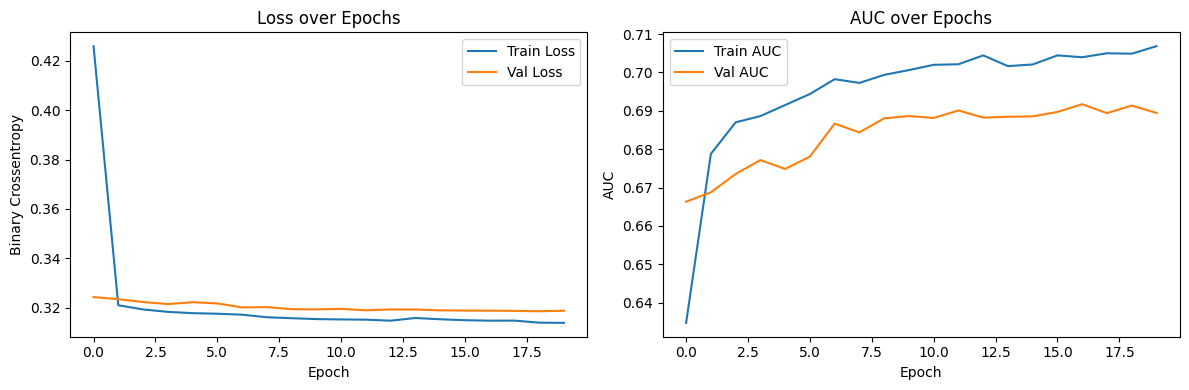

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.epoch, history.history['binary_crossentropy'], label='Train Loss')
axes[0].plot(history.epoch, history.history['val_binary_crossentropy'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()

axes[1].plot(history.epoch, history.history['auc'], label='Train AUC')
axes[1].plot(history.epoch, history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

## Final Model & Artifacts

In [24]:

torch.save(model.state_dict(), 'deepfm_final.pt')


with open('feature_columns.pkl', 'wb') as f:
    cloudpickle.dump(fixlen_feature_columns, f)


model_config = {
    'dnn_hidden_units': (128, 64, 32),
    'dnn_dropout': 0.3,
    'embedding_dim': 4,
    'optimizer': 'adam',
    'epochs': 20,
    'batch_size': 256,
    'dense_features': dense_features,
    'sparse_features': sparse_features,
    'saved_at': datetime.now().strftime('%Y-%m-%d %H:%M')
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Saved: deepfm_final.pt, feature_columns.pkl, model_config.json")

Saved: deepfm_final.pt, feature_columns.pkl, model_config.json


### Full Evaluation on Test Set

In [25]:
test_preds = model.predict(test_input, batch_size=256).flatten()

def compute_ndcg_at_k(df_eval, preds, k=10):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    ndcg_scores = []
    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values
        dcg  = sum([rel / np.log2(rank + 2) for rank, rel in enumerate(relevance[:k])])
        ideal = group.sort_values('label', ascending=False)['label'].values
        idcg = sum([rel / np.log2(rank + 2) for rank, rel in enumerate(ideal[:k])])
        if idcg > 0:
            ndcg_scores.append(dcg / idcg)
    return np.mean(ndcg_scores)


def compute_map(df_eval, preds):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    ap_scores = []
    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values

        if relevance.sum() == 0:
            continue
        num_relevant = 0
        precisions = []
        for rank, rel in enumerate(relevance):
            if rel == 1:
                num_relevant += 1
                precisions.append(num_relevant / (rank + 1))
        ap_scores.append(np.mean(precisions))
    return np.mean(ap_scores)

def compute_mrr(df_eval, preds):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    rr_scores = []
    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values
        for rank, rel in enumerate(relevance):
            if rel == 1:
                rr_scores.append(1 / (rank + 1))
                break
        else:
            rr_scores.append(0)
    return np.mean(rr_scores)


def compute_precision_at_k(df_eval, preds, k=10):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    p_scores = []
    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values[:k]
        p_scores.append(relevance.sum() / k)
    return np.mean(p_scores)


### Computing Metrics

In [26]:
print(f"test_preds length : {len(test_preds)}")
print(f"test_df length    : {len(test_df)}")  # must match
print(f"Unique queries in test: {test_df['query_id'].nunique()}")
print(f"Avg passages per query: {len(test_df) / test_df['query_id'].nunique():.1f}")

test_preds length : 8146
test_df length    : 8146
Unique queries in test: 816
Avg passages per query: 10.0


In [27]:
ndcg_5  = compute_ndcg_at_k(test_df, test_preds, k=5)
ndcg_10 = compute_ndcg_at_k(test_df, test_preds, k=10)
map_score = compute_map(test_df, test_preds)
mrr = compute_mrr(test_df, test_preds)
p_at_5  = compute_precision_at_k(test_df, test_preds, k=5)
p_at_10 = compute_precision_at_k(test_df, test_preds, k=10)


print("       FINAL EVALUATION RESULTS")
print(f"  NDCG@5       : {ndcg_5:.4f}")
print(f"  NDCG@10      : {ndcg_10:.4f}")
print(f"  MAP          : {map_score:.4f}")
print(f"  MRR          : {mrr:.4f}")
print(f"  Precision@5  : {p_at_5:.4f}")
print(f"  Precision@10 : {p_at_10:.4f}")


results = {
    'NDCG@5': round(ndcg_5, 4),
    'NDCG@10': round(ndcg_10, 4),
    'MAP': round(map_score, 4),
    'MRR': round(mrr, 4),
    'Precision@5': round(p_at_5, 4),
    'Precision@10': round(p_at_10, 4)
}

with open('evaluation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n Results saved to evaluation_results.json")


       FINAL EVALUATION RESULTS
  NDCG@5       : 0.5422
  NDCG@10      : 0.6139
  MAP          : 0.4899
  MRR          : 0.4951
  Precision@5  : 0.1657
  Precision@10 : 0.1060

 Results saved to evaluation_results.json


### Training Curves

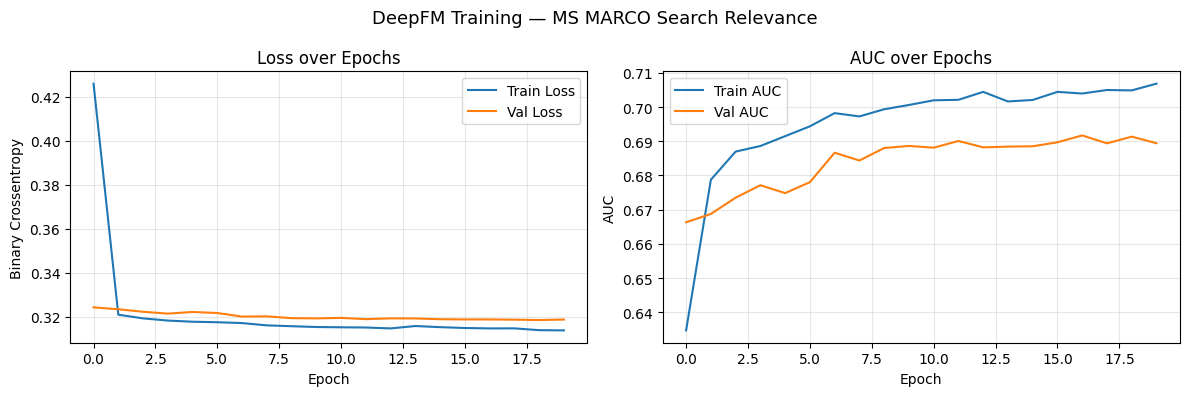

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.epoch, history.history['binary_crossentropy'], label='Train Loss')
axes[0].plot(history.epoch, history.history['val_binary_crossentropy'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.epoch, history.history['auc'], label='Train AUC')
axes[1].plot(history.epoch, history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('DeepFM Training — MS MARCO Search Relevance', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Experiments Summmary

In [29]:
experiments = pd.DataFrame({
    'Run': ['Baseline', 'Oversampled', 'Wider Architecture', 'Adagrad Optimizer'],
    'Architecture': ['(64, 32)', '(64, 32)', '(128, 64, 32)', '(128, 64, 32)'],
    'Optimizer': ['Adam', 'Adam', 'Adam', 'Adagrad'],
    'Imbalance Handling': ['None', 'Oversample', 'None', 'None'],
    'NDCG@10': [0.8503, 0.8465, 0.8511, 0.8483],
    'MAP': [0.7984, 0.7935, 0.7995, 0.7958]
})

experiments['Best'] = experiments['NDCG@10'] == experiments['NDCG@10'].max()
print("\n Experiment Summary:")
print(experiments.to_string(index=False))


 Experiment Summary:
               Run  Architecture Optimizer Imbalance Handling  NDCG@10    MAP  Best
          Baseline      (64, 32)      Adam               None   0.8503 0.7984 False
       Oversampled      (64, 32)      Adam         Oversample   0.8465 0.7935 False
Wider Architecture (128, 64, 32)      Adam               None   0.8511 0.7995  True
 Adagrad Optimizer (128, 64, 32)   Adagrad               None   0.8483 0.7958 False
